# Análise completa de ram pressure + tidal stripping para simulações ORBIT

Este notebook foi feito para uma estrutura como:

```text
./SIMULATIONS/ORBIT/HigherRes/E_mid_L_mid/output/snapshot_XXX.hdf5
```

Ele faz quatro coisas principais:

1. Descobre automaticamente uma ou mais simulações.
2. Roda a análise física com `dwarf_ram_analysis_ids.py`.
3. Compara ram pressure, maré, gás, SFR, tamanhos e stripping.
4. Cria mapas PNG e um GIF da órbita.

A ideia é que você possa trocar apenas `LABELS` e os centros iniciais para analisar outras simulações.

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
from IPython.display import display, Image, Markdown, HTML
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

warnings.filterwarnings("ignore")
sys.path.append(os.getenv("HOME")+"/PROJECTS/2026/Dwarf_Galaxies_RP_TS/src")

# Preferência: usar a versão com ParticleIDs.
try:
    import dwarf_ram_analysis_ids as dra
    print("Using dwarf_ram_analysis_ids.py")
except Exception as exc:
    print("Could not import dwarf_ram_analysis_ids.py:", exc)
    print("Falling back to dwarf_ram_analysis.py")
    import dwarf_ram_analysis as dra

import orbit_ram_tidal_pipeline as ort

plt.style.use("./../src/abhner.mplstyle")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using dwarf_ram_analysis_ids.py


## 1. Caminhos do projeto

In [5]:
PROJECT_ROOT = Path("./../").resolve()

# Estrutura mostrada no screenshot:
SIM_ROOT = PROJECT_ROOT / "SIMULATIONS" / "ORBIT"
SUITE = "HigherRes"

# Coloque None para detectar todas as simulações dentro de HigherRes.
# Ou use uma lista, por exemplo: ["E_mid_L_mid", "E_high_L_low"].
LABELS = ["E_mid_L_mid"]

ANALYSIS_ROOT = PROJECT_ROOT / "ANALYSIS" / "ORBIT"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SIM_ROOT:", SIM_ROOT)
print("ANALYSIS_ROOT:", ANALYSIS_ROOT)

PROJECT_ROOT: /home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_TS
SIM_ROOT: /home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_TS/SIMULATIONS/ORBIT
ANALYSIS_ROOT: /home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_TS/ANALYSIS/ORBIT


## 2. Descobrir as simulações disponíveis

In [6]:
sims = ort.discover_simulations(
    sim_root=SIM_ROOT,
    suite=SUITE,
    labels=LABELS,
    output_name="output",
    recursive=True,
)

sims

,label,suite,sim_dir,output_dir,n_snapshots,first_snapshot,last_snapshot
0,E_mid_L_mid,HigherRes,/home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_T...,/home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_T...,51,snapshot_000.hdf5,snapshot_050.hdf5


Se a tabela acima estiver vazia, cheque se você está executando o notebook no diretório correto.  
No seu caso, o notebook deve estar idealmente na pasta raiz do projeto, algo como:

```text
Dwarf_Galaxies_RP_TS/
```

## 3. Configuração física da análise

In [7]:
# -------------------------------------------------------------------
# Centros iniciais
# -------------------------------------------------------------------
# Ajuste esses valores.
# Eles são usados como chute inicial para localizar a dwarf e para definir o centro do host.
#
# Para sua estrutura atual, o label principal é E_mid_L_mid.
# Se cada simulação tiver centros diferentes, use PER_LABEL_DWARF_CENTERS e PER_LABEL_HOST_CENTERS.

DWARF_INIT_CENTER = [203.623, 108.599, 0.0]
HOST_CENTER = [0.0, 0.0, 0.0]

PER_LABEL_DWARF_CENTERS = {
    # "E_mid_L_mid": [x0, y0, z0],
    # "ORBIT02": [250, 150, 0.0],
}

PER_LABEL_HOST_CENTERS = {
    # "E_mid_L_mid": [xh, yh, zh],
}

# -------------------------------------------------------------------
# Parâmetros da análise
# -------------------------------------------------------------------
CONFIG_KWARGS = dict(
    track_host=False,

    # Tracking e abertura da dwarf
    search_radius=15.0,
    host_search_radius=30.0,
    aperture_factor=2.0,
    young_age_myr=100.0,

    # CGM / ram pressure
    cgm_rin=3.0,
    cgm_rout=10.0,
    cgm_temp_min=1e5,
    cgm_density_max=None,
    cgm_estimator="cone",
    cone_half_angle_deg=35.0,
    cone_min_cells=8,
    require_inflow_in_cone=False,

    # Maré
    tidal_delta_kpc=1.0,

    # Testes rápidos
    max_snaps=None,

    # ----------------------------------------------------------------
    # Parte nova baseada em ParticleIDs
    # ----------------------------------------------------------------
    # Como no seu caso somente a dwarf tem estrelas, podemos usar as
    # estrelas do primeiro snapshot como origem estelar da dwarf.
    use_particle_ids=True,
    origin_all_stars_are_dwarf=True,

    # Se None, o script usa:
    # max(origin_min_radius_kpc, origin_dwarf_aperture_factor * Rhalf_initial)
    # para definir gás/DM inicial da dwarf.
    origin_dwarf_radius_kpc=None,
    origin_dwarf_aperture_factor=5.0,
    origin_min_radius_kpc=5.0,

    # Restrição principal: CGM = gás de origem do host.
    restrict_cgm_to_host_gas_ids=True,

    # Stripping por IDs + critério radial/tidal.
    measure_id_stripping=True,
    stripped_radius_factor=2.0,
    stripped_use_tidal_radius=True,
)

CONFIG_KWARGS

{'track_host': False,
 'search_radius': 15.0,
 'host_search_radius': 30.0,
 'aperture_factor': 2.0,
 'young_age_myr': 100.0,
 'cgm_rin': 3.0,
 'cgm_rout': 10.0,
 'cgm_temp_min': 100000.0,
 'cgm_density_max': None,
 'cgm_estimator': 'cone',
 'cone_half_angle_deg': 35.0,
 'cone_min_cells': 8,
 'require_inflow_in_cone': False,
 'tidal_delta_kpc': 1.0,
 'max_snaps': None,
 'use_particle_ids': True,
 'origin_all_stars_are_dwarf': True,
 'origin_dwarf_radius_kpc': None,
 'origin_dwarf_aperture_factor': 5.0,
 'origin_min_radius_kpc': 5.0,
 'restrict_cgm_to_host_gas_ids': True,
 'measure_id_stripping': True,
 'stripped_radius_factor': 2.0,
 'stripped_use_tidal_radius': True}

### Interpretação da parte por IDs

A regra usada aqui é:

```text
ID → origem da partícula
posição / raio de maré / abertura → estado atual
```

Então:

```text
CGM local = gás de origem do host + shell/cone em torno da dwarf + cortes de temperatura/densidade
```

e:

```text
estrela stripped = estrela originalmente da dwarf + fora do critério radial/tidal atual
```

Isso evita contar gás arrancado da própria dwarf como se fosse CGM do host.

## 4. Rodar a análise de ram pressure + maré + stripping

In [8]:
FORCE_REANALYZE = False
TABLE_NAME = "dwarf_ram_pressure_evolution_final.txt"

analysis_table = ort.run_analysis_table_for_simulations(
    dra=dra,
    sims=sims,
    analysis_root=ANALYSIS_ROOT,
    dwarf_init_center=DWARF_INIT_CENTER,
    host_center=HOST_CENTER,
    per_label_dwarf_centers=PER_LABEL_DWARF_CENTERS,
    per_label_host_centers=PER_LABEL_HOST_CENTERS,
    table_name=TABLE_NAME,
    force_reanalyze=FORCE_REANALYZE,
    keep_suite=True,
    config_kwargs=CONFIG_KWARGS,
    verbose=True,
)

analysis_table

[RUN ] E_mid_L_mid: /home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_TS/SIMULATIONS/ORBIT/HigherRes/E_mid_L_mid/output
      outdir: /home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_TS/ANALYSIS/ORBIT/HigherRes/E_mid_L_mid
[INFO] Creating origin ID catalog from: snapshot_000.hdf5


yt : [INFO     ] 2026-05-19 10:07:34,686 Omega Lambda is 0.0, so we are turning off Cosmology.
yt : [INFO     ] 2026-05-19 10:07:34,686 Assuming length units are in kpc (physical)
yt : [INFO     ] 2026-05-19 10:07:34,747 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-05-19 10:07:34,748 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2026-05-19 10:07:34,749 Parameters: domain_left_edge          = None
yt : [INFO     ] 2026-05-19 10:07:34,750 Parameters: domain_right_edge         = None
yt : [INFO     ] 2026-05-19 10:07:34,750 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-05-19 10:07:34,890 Allocating for 3.255e+05 particles
yt : [INFO     ] 2026-05-19 10:07:34,891 Bounding box cannot be inferred from metadata, reading particle positions to infer bounding box
yt : [INFO     ] 2026-05-19 10:07:34,963 Load this dataset with bounding_box=[[-249.10317993 -247.83924866 -249.14125061], [249.80577087 249.59608459 248.24980164]] to avoid I/O 

[INFO] Wrote origin ID catalog: /home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_TS/ANALYSIS/ORBIT/HigherRes/E_mid_L_mid/origin_particle_ids.npz
       N dwarf stars: 7584
       N dwarf gas:   15699
       N host gas:    231540
[0001/0051] snapshot_000.hdf5


yt : [INFO     ] 2026-05-19 10:07:36,914 Omega Lambda is 0.0, so we are turning off Cosmology.
yt : [INFO     ] 2026-05-19 10:07:36,915 Assuming length units are in kpc (physical)
yt : [INFO     ] 2026-05-19 10:07:36,962 Parameters: current_time              = 0.107421875
yt : [INFO     ] 2026-05-19 10:07:36,963 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2026-05-19 10:07:36,963 Parameters: domain_left_edge          = None
yt : [INFO     ] 2026-05-19 10:07:36,964 Parameters: domain_right_edge         = None
yt : [INFO     ] 2026-05-19 10:07:36,964 Parameters: cosmological_simulation   = 0


[0002/0051] snapshot_001.hdf5


...

yt : [INFO     ] 2026-05-19 10:08:15,595 Omega Lambda is 0.0, so we are turning off Cosmology.
yt : [INFO     ] 2026-05-19 10:08:15,596 Assuming length units are in kpc (physical)
yt : [INFO     ] 2026-05-19 10:08:15,626 Parameters: current_time              = 5.392578125
yt : [INFO     ] 2026-05-19 10:08:15,627 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2026-05-19 10:08:15,627 Parameters: domain_left_edge          = None
yt : [INFO     ] 2026-05-19 10:08:15,628 Parameters: domain_right_edge         = None
yt : [INFO     ] 2026-05-19 10:08:15,629 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-05-19 10:08:15,637 Allocating for 3.255e+05 particles
yt : [INFO     ] 2026-05-19 10:08:15,637 Bounding box cannot be inferred from metadata, reading particle positions to infer bounding box


[0050/0051] snapshot_049.hdf5


yt : [INFO     ] 2026-05-19 10:08:15,658 Load this dataset with bounding_box=[[ -927.70672607 -1113.5994873   -975.40313721], [879.58966064 903.40087891 913.72595215]] to avoid I/O overhead from inferring bounding_box.
yt : [INFO     ] 2026-05-19 10:08:16,166 Omega Lambda is 0.0, so we are turning off Cosmology.
yt : [INFO     ] 2026-05-19 10:08:16,167 Assuming length units are in kpc (physical)
yt : [INFO     ] 2026-05-19 10:08:16,200 Parameters: current_time              = 5.5
yt : [INFO     ] 2026-05-19 10:08:16,201 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2026-05-19 10:08:16,202 Parameters: domain_left_edge          = None
yt : [INFO     ] 2026-05-19 10:08:16,202 Parameters: domain_right_edge         = None
yt : [INFO     ] 2026-05-19 10:08:16,203 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-05-19 10:08:16,212 Allocating for 3.255e+05 particles
yt : [INFO     ] 2026-05-19 10:08:16,213 Bounding box cannot be inferred from metadata, reading 

[0051/0051] snapshot_050.hdf5


,label,suite,output_dir,analysis_dir,table_path,status,n_records_computed
0,E_mid_L_mid,HigherRes,/home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_T...,/home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_T...,/home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_T...,computed,51


## 5. Carregar as tabelas como objetos `RunData`

In [9]:
runs = ort.prepare_runs_from_analysis_table(
    dra=dra,
    analysis_table=analysis_table,
    smooth=5,
    pre_window=(-0.5, -0.1),
    force_window=(-0.3, 0.3),
    response_window=(-0.1, 1.0),
    entry_radius_kpc=250.0,
    gas_loss_fraction=0.05,
    gas_loss_mode="total",
    min_gas_floor_abs=1e5,
)

for run in runs:
    print(f"{run.label}: N={len(run.t)}, t_peri={run.t_peri:.3f} Gyr")
    print("  table:", run.table_path)

E_mid_L_mid: N=51, t_peri=1.077 Gyr
  table: /home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_TS/ANALYSIS/ORBIT/HigherRes/E_mid_L_mid/dwarf_ram_pressure_evolution_final.txt


## 6. Métricas principais

In [10]:
metrics_path = ANALYSIS_ROOT / SUITE / "summary_metrics.csv"
metrics_df = ort.metrics_dataframe(dra, runs, outpath=metrics_path)
print("Saved:", metrics_path)

cols_priority = [
    "label", "d_peri_kpc", "t_peri_gyr",
    "pram_peak", "tau_pram_peak",
    "tidal_peak", "tau_tidal_peak",
    "star_norm_min", "tau_star_norm_min",
    "young_norm_min", "tau_young_norm_min",
    "gas_sf_norm_min", "tau_gas_sf_norm_min",
    "fstar_dwarf_origin_stripped",
    "fgas_dwarf_origin_stripped",
]
metrics_df[[c for c in cols_priority if c in metrics_df.columns]]

Saved: /home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_TS/ANALYSIS/ORBIT/HigherRes/summary_metrics.csv


,label,d_peri_kpc,t_peri_gyr,pram_peak,tau_pram_peak,tidal_peak,tau_tidal_peak,star_norm_min,tau_star_norm_min,young_norm_min,tau_young_norm_min,gas_sf_norm_min,tau_gas_sf_norm_min
0,E_mid_L_mid,128.253383,1.076622,NaN,NaN,0.000172,0.0,0.848607,0.0,NaN,NaN,0.853114,0.0


## 7. Painel global: forcing externo e resposta da dwarf

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


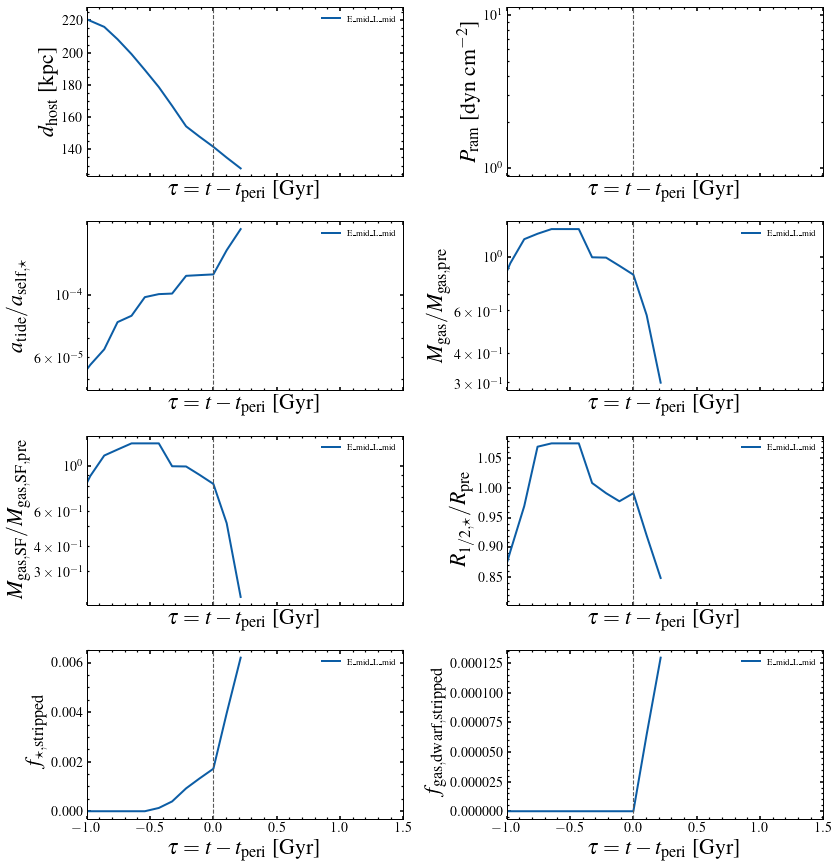

In [11]:
fig = ort.plot_forcing_response_panel(
    runs,
    xlim=(-1.0, 1.5),
    smooth=5,
    pre_window=(-0.5, -0.1),
)
plt.show()

## 8. Plots individuais customizados

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


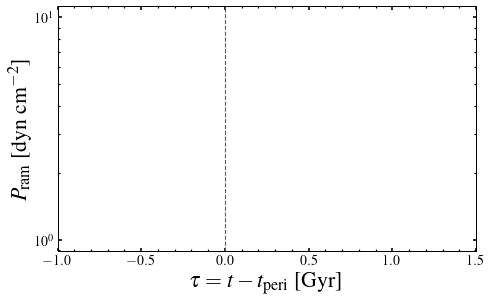

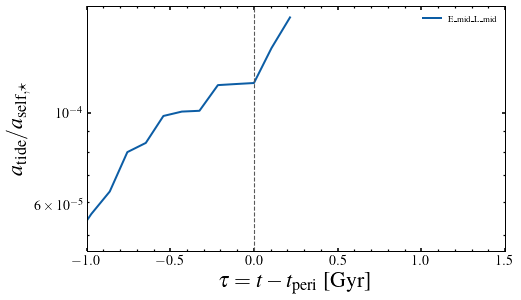

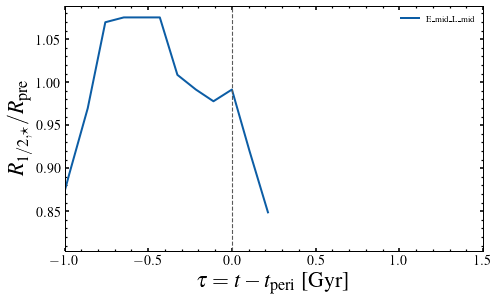

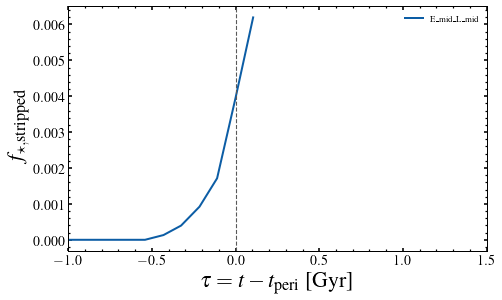

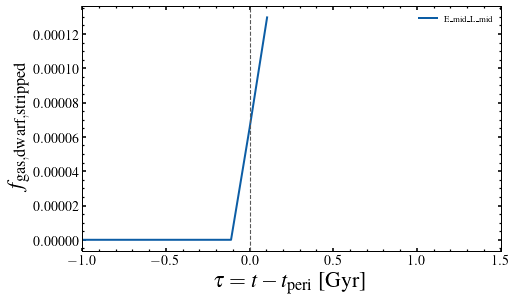

In [12]:
# Ram pressure
pram_col = "pram_upstream_dyn_cm2"
if len(runs) and pram_col not in runs[0].cols:
    pram_col = "pram_dyn_cm2"

ort.plot_runs_quantity(
    runs,
    pram_col,
    ylabel=r"$P_{\rm ram}$ [dyn cm$^{-2}$]",
    logy=True,
    smooth=5,
    xlim=(-1.0, 1.5),
)
plt.show()

# Tidal forcing
ort.plot_runs_quantity(
    runs,
    "tidal_to_self_star",
    ylabel=r"$a_{\rm tide}/a_{\rm self,\star}$",
    logy=True,
    smooth=5,
    xlim=(-1.0, 1.5),
)
plt.show()

# Tamanho estelar normalizado
ort.plot_runs_quantity(
    runs,
    "rhalf_star_kpc",
    ylabel=r"$R_{1/2,\star}/R_{\rm pre}$",
    normalized=True,
    smooth=5,
    xlim=(-1.0, 1.5),
)
plt.show()

# Fração de estrelas stripped por IDs
if len(runs) and "fstar_dwarf_origin_stripped" in runs[0].cols:
    ort.plot_runs_quantity(
        runs,
        "fstar_dwarf_origin_stripped",
        ylabel=r"$f_{\star,\rm stripped}$",
        smooth=3,
        xlim=(-1.0, 1.5),
    )
    plt.show()

# Fração de gás da dwarf stripped por IDs
if len(runs) and "fgas_dwarf_origin_stripped" in runs[0].cols:
    ort.plot_runs_quantity(
        runs,
        "fgas_dwarf_origin_stripped",
        ylabel=r"$f_{\rm gas,dwarf,stripped}$",
        smooth=3,
        xlim=(-1.0, 1.5),
    )
    plt.show()

## 9. Usar `dwarf_ram_plots.py`, se disponível

In [ ]:
try:
    import dwarf_ram_plots as drp
    HAS_DRP = True
    print("dwarf_ram_plots.py available.")
except Exception as exc:
    HAS_DRP = False
    print("dwarf_ram_plots.py unavailable:", exc)

if HAS_DRP:
    compare_dir = ANALYSIS_ROOT / SUITE / "compare_standard_plots"
    compare_dir.mkdir(parents=True, exist_ok=True)
    paths = drp.make_comparison_plot_set(runs, outdir=str(compare_dir), xlim=(-1.0, 1.5))
    print("Generated", len(paths), "files in", compare_dir)

## 10. Mapas rápidos dos snapshots

E_mid_L_mid maps: 3 -> /home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_TS/ANALYSIS/ORBIT/HigherRes/E_mid_L_mid/maps


### /home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_TS/ANALYSIS/ORBIT/HigherRes/E_mid_L_mid/maps/map_snapshot_000_z.png

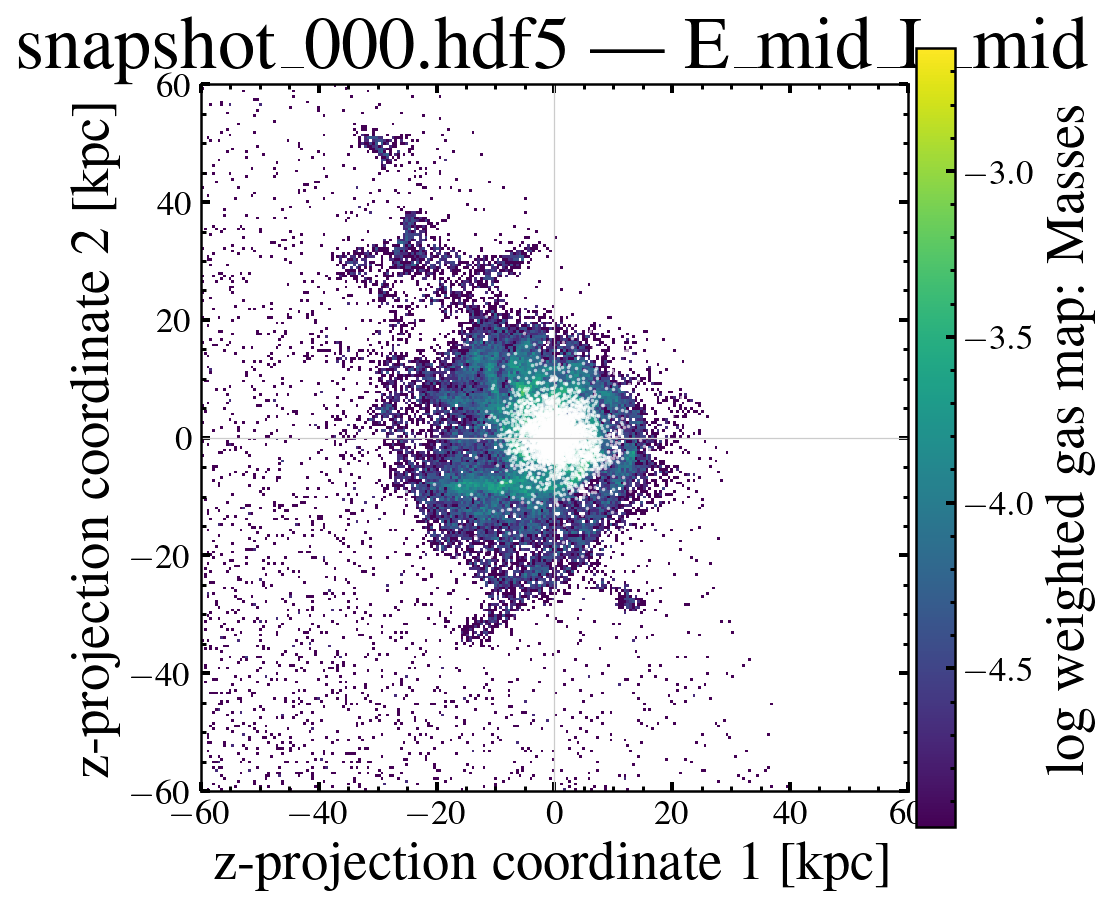

### /home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_TS/ANALYSIS/ORBIT/HigherRes/E_mid_L_mid/maps/map_snapshot_005_z.png

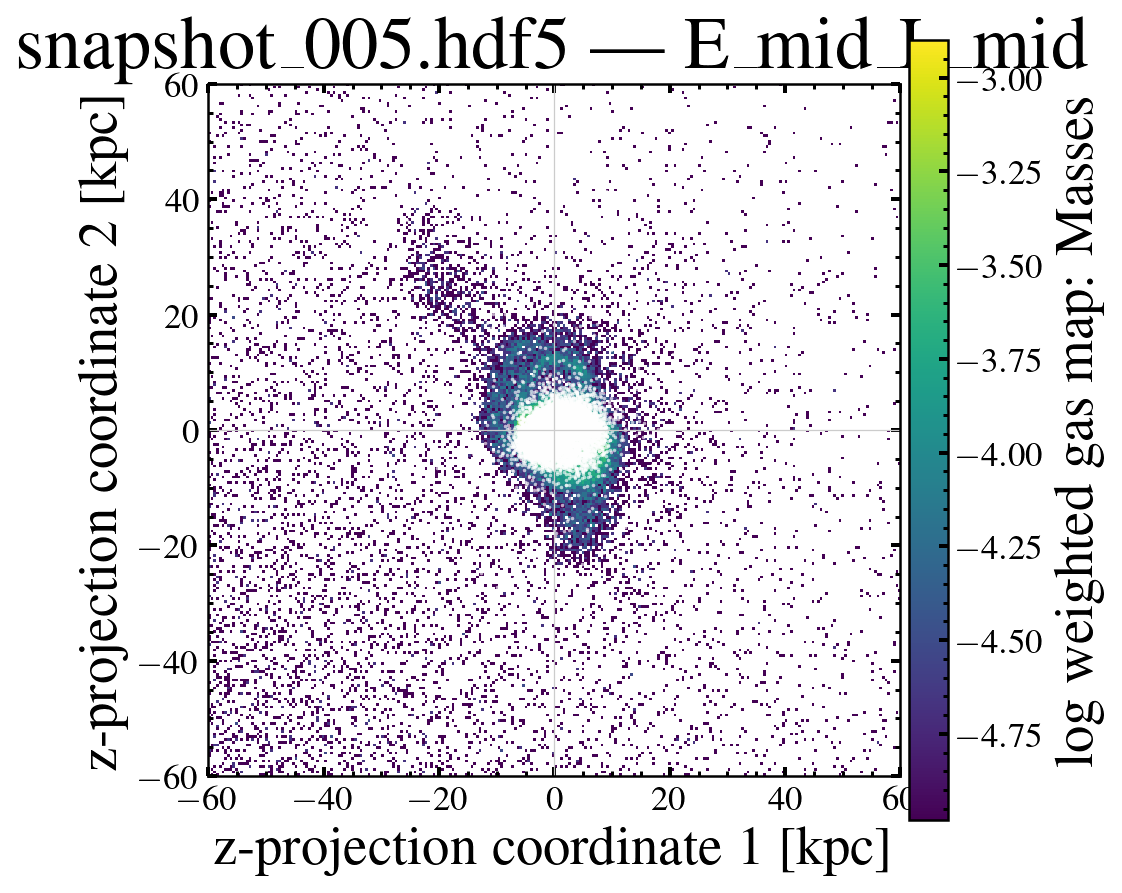

### /home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_TS/ANALYSIS/ORBIT/HigherRes/E_mid_L_mid/maps/map_snapshot_010_z.png

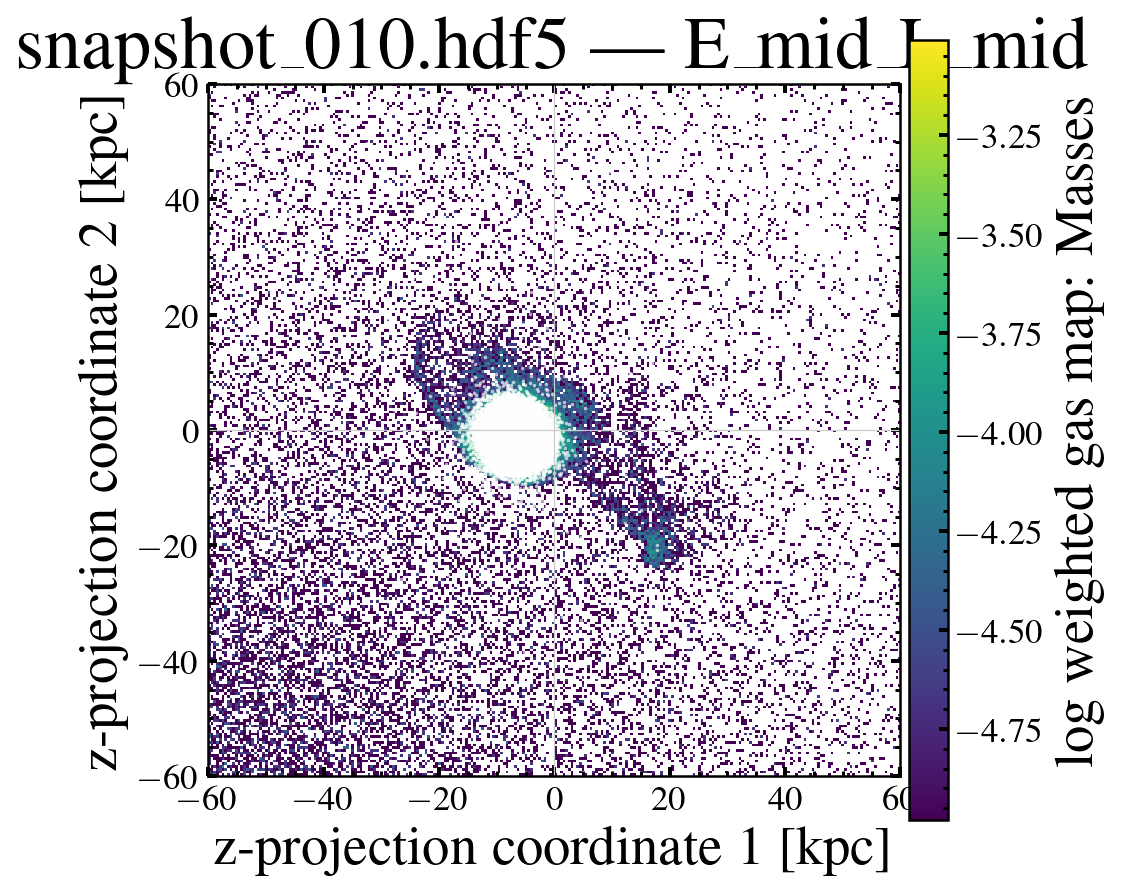

In [13]:
# Mapas feitos diretamente dos HDF5 com h5py.
# Eles são para inspeção visual: gás como mapa 2D e estrelas sobrepostas.
# A análise quantitativa principal continua vindo de dwarf_ram_analysis_ids.py.

MAKE_MAPS = True
MAP_EVERY = 5           # use 1 para todos os snapshots; 5 ou 10 para teste rápido
MAP_MAX_SNAPS = None    # ex.: 5 para teste
MAP_WIDTH_KPC = 120.0
MAP_BINS = 256
MAP_AXIS = "z"

all_map_outputs = {}

if MAKE_MAPS:
    for _, row in analysis_table.iterrows():
        label = row["label"]
        suite = row["suite"]
        output_dir = Path(row["output_dir"])
        table_path = Path(row["table_path"])
        map_dir = ANALYSIS_ROOT / suite / label / "maps"

        outputs = ort.make_map_series(
            output_dir=output_dir,
            outdir=map_dir,
            table_path=table_path,
            center_mode="table",
            axis=MAP_AXIS,
            width_kpc=MAP_WIDTH_KPC,
            bins=MAP_BINS,
            max_snaps=MAP_MAX_SNAPS,
            every=MAP_EVERY,
            sfr_only=False,
            gas_weight="Masses",
            convert_coords_to_kpc=True,
        )
        all_map_outputs[label] = outputs
        print(label, "maps:", len(outputs), "->", map_dir)

        # Mostra algumas imagens no notebook
        for p in outputs[:3]:
            display(Markdown(f"### {p}"))
            display(Image(filename=str(p), width=650))

## 11. Mapas apenas do gás formador de estrelas

In [14]:
MAKE_SFR_MAPS = False

if MAKE_SFR_MAPS:
    for _, row in analysis_table.iterrows():
        label = row["label"]
        suite = row["suite"]
        output_dir = Path(row["output_dir"])
        table_path = Path(row["table_path"])
        map_dir = ANALYSIS_ROOT / suite / label / "maps_sfr_only"

        outputs = ort.make_map_series(
            output_dir=output_dir,
            outdir=map_dir,
            table_path=table_path,
            center_mode="table",
            axis=MAP_AXIS,
            width_kpc=MAP_WIDTH_KPC,
            bins=MAP_BINS,
            max_snaps=MAP_MAX_SNAPS,
            every=MAP_EVERY,
            sfr_only=True,
            gas_weight="StarFormationRate",
            convert_coords_to_kpc=True,
        )
        print(label, "SFR maps:", len(outputs), "->", map_dir)

## 12. GIF da órbita

In [15]:
MAKE_ORBIT_GIF = True

orbit_gifs = {}

if MAKE_ORBIT_GIF:
    for _, row in analysis_table.iterrows():
        label = row["label"]
        suite = row["suite"]
        table_path = Path(row["table_path"])
        gif_dir = ANALYSIS_ROOT / suite / label / "gifs"

        gif = ort.make_orbit_gif(
            table_path=table_path,
            outdir=gif_dir,
            label=label,
            duration=0.12,
            dpi=140,
        )
        orbit_gifs[label] = gif
        print(label, "orbit gif:", gif)

        if gif is not None and Path(gif).exists():
            display(HTML(f'<img src="{gif}" width="520">'))

E_mid_L_mid orbit gif: /home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_TS/ANALYSIS/ORBIT/HigherRes/E_mid_L_mid/gifs/orbit_E_mid_L_mid.gif


## 13. GIF dos mapas, se desejar

In [16]:
MAKE_MAP_GIF = False

if MAKE_MAP_GIF:
    for label, outputs in all_map_outputs.items():
        if len(outputs) == 0:
            continue
        suite = analysis_table.loc[analysis_table["label"] == label, "suite"].iloc[0]
        gif_dir = ANALYSIS_ROOT / suite / label / "gifs"
        gif = ort.make_gif_from_frames(
            outputs,
            gif_dir / f"maps_{label}.gif",
            duration=0.16,
        )
        print(label, "map gif:", gif)
        if gif is not None:
            display(HTML(f'<img src="{gif}" width="520">'))

## 14. Relatório simples em Markdown

In [17]:
report_path = ANALYSIS_ROOT / SUITE / "ram_pressure_tidal_summary.md"
ort.write_run_summary_markdown(metrics_df, report_path)
print("Saved:", report_path)

display(Markdown(report_path.read_text(encoding="utf-8")))

Saved: /home/abhner/PROJECTS/2026/Dwarf_Galaxies_RP_TS/ANALYSIS/ORBIT/HigherRes/ram_pressure_tidal_summary.md


# Ram-pressure and tidal stripping summary

## Runs

### E_mid_L_mid
- `d_peri_kpc`: 1.2825e+02
- `t_peri_gyr`: 1.0766e+00
- `tidal_peak`: 1.7178e-04
- `tau_tidal_peak`: 0.0000e+00
- `star_norm_min`: 8.4861e-01
- `gas_sf_norm_min`: 8.5311e-01


## 15. Checklist científico

Depois de rodar, eu verificaria nesta ordem:

1. O tracking da dwarf está correto?  
   Verifique `x_kpc`, `y_kpc`, `z_kpc`, `dist_host_kpc` e os mapas.

2. O pericentro faz sentido?  
   O tempo `tau=0` deve coincidir com o mínimo de `dist_host_kpc`.

3. O CGM foi restringido ao gás de origem do host?  
   Se a versão por IDs estiver ativa, cheque a coluna `cgm_host_id_restricted`.

4. O pico de ram pressure coincide com pericentro?  
   Compare `tau_pram_peak` e `tau_tidal_peak`.

5. A contração estelar ocorre antes ou depois da perda de gás?  
   Compare `rhalf_star_kpc`, `mgas_msun`, `mgas_sf_msun`, SFR e frações stripped.

6. O stripping estelar é real ou apenas expansão/oscillação?  
   Use a fração `fstar_dwarf_origin_stripped` junto com mapas e raio de maré.